# Renewable Energy Shift, 2014–2024
### The Real Movers: who actually shifted to renewable energy

Iceland, Norway and Canada lead most renewable-energy rankings. They got there decades ago by building hydropower on large rivers. A ranking by *level* mostly rewards geography.

This notebook asks a different question: **between 2014 and 2024, which countries actually moved, and what moved them?**

**Data.** Our World in Data energy dataset (CC BY 4.0), compiled from:
- Energy Institute, *Statistical Review of World Energy*: renewable share of **primary energy**, using the substitution method.
- Ember and Energy Institute: renewable share of **electricity generation**.

The cleaned files in `data/processed/` are produced by `scripts/build.py`. Run that first to pull the latest data.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed"

BASE, END = 2014, 2024
SOURCES = ["hydro", "wind", "solar", "other"]
COLORS = {"hydro": "#5b9ddf", "wind": "#5acaaf", "solar": "#eba051", "other": "#d073b3", "flat": "#b8b8b8"}
LABELS = {"hydro": "Hydro", "wind": "Wind", "solar": "Solar", "other": "Other renewables"}

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.6),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#eeeeee",
    "text.color": "#121212", "axes.labelcolor": "#121212", "axes.edgecolor": "#999999",
    "xtick.color": "#6b6b6b", "ytick.color": "#6b6b6b", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "font.size": 10,
})
pd.set_option("display.precision", 2)

## 2. Load the data

In [2]:
energy = pd.read_csv(DATA / "renewables_share_primary_energy_2000_2024.csv")
elec = pd.read_csv(DATA / "renewables_share_electricity_2010_2024.csv")

for name, df in [("Primary energy", energy), ("Electricity", elec)]:
    n = df.loc[df.iso_code != "WLD", "country"].nunique()
    print(f"{name:15} {len(df):>5} rows   {n:>3} countries   {df.year.min()}–{df.year.max()}")

energy.head()

Primary energy   2000 rows    79 countries   2000–2024
Electricity      3174 rows   212 countries   2010–2024


,country,iso_code,year,population,primary_energy_twh,renewables_pct,hydro_pct,wind_pct,solar_pct,other_pct,nuclear_pct,fossil_pct
0,Algeria,DZA,2000,30903894.00,299.95,0.05,0.05,0.00,0.00,0.00,0.00,99.95
1,Algeria,DZA,2001,31331226.00,310.81,0.06,0.06,0.00,0.00,0.00,0.00,99.94
2,Algeria,DZA,2002,31750832.00,321.95,0.05,0.05,0.00,0.00,0.00,0.00,99.95
3,Algeria,DZA,2003,32175813.00,336.92,0.21,0.21,0.00,0.00,0.00,0.00,99.79
4,Algeria,DZA,2004,32628286.00,349.78,0.19,0.19,0.00,0.00,0.00,0.00,99.81


## 3. Data checks

Before any analysis, three things need to hold:

1. **The sources add up.** Hydro, wind, solar and other renewables should sum to the reported renewables total, apart from rounding.
2. **One row per country-year.** No duplicates, so no country is counted twice.
3. **The coverage is clear.** I need to know which countries are missing before drawing global conclusions.

In [3]:
for name, df in [("Primary energy", energy), ("Electricity", elec)]:
    gap = (df[[f"{s}_pct" for s in SOURCES]].sum(axis=1) - df["renewables_pct"]).abs().max()
    dupes = df.duplicated(["country", "year"]).sum()
    print(f"{name:15} max gap between sources and total: {gap:.2f} pts   duplicate rows: {dupes}")

Primary energy  max gap between sources and total: 0.02 pts   duplicate rows: 0
Electricity     max gap between sources and total: 0.02 pts   duplicate rows: 0


In [4]:
AFRICA = {"DZA","AGO","BEN","BWA","BFA","BDI","CPV","CMR","CAF","TCD","COM","COD","COG","CIV","DJI","EGY",
          "GNQ","ERI","SWZ","ETH","GAB","GMB","GHA","GIN","GNB","KEN","LSO","LBR","LBY","MDG","MWI","MLI",
          "MRT","MUS","MAR","MOZ","NAM","NER","NGA","RWA","STP","SEN","SYC","SLE","SOM","ZAF","SSD","SDN",
          "TZA","TGO","TUN","UGA","ZMB","ZWE","ESH"}

af_energy = sorted(energy.loc[energy.iso_code.isin(AFRICA), "country"].unique())
af_elec = elec.loc[(elec.year == END) & elec.iso_code.isin(AFRICA), "country"].nunique()
print("African countries in the primary-energy series:", ", ".join(af_energy))
print(f"African countries in the electricity series ({END}):", af_elec)

African countries in the primary-energy series: Algeria, Egypt, Morocco, South Africa
African countries in the electricity series (2024): 50


The primary-energy series covers only four African countries. The rest of the continent is reported only as a regional total. Global findings below hold for the countries covered, not for every country. The electricity series is used later as a robustness check, partly because its coverage is wider.

## 4. The world: wind and solar passed hydro in 2024

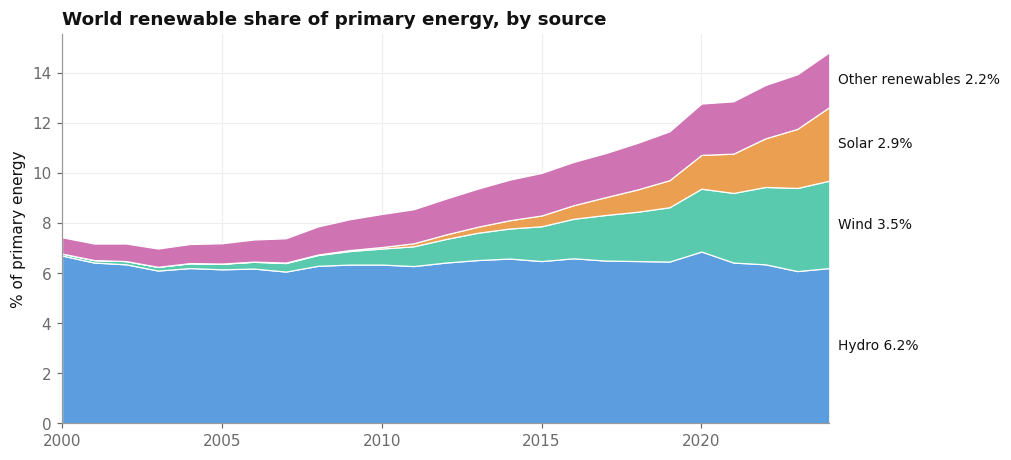

In [5]:
world = energy[energy.iso_code == "WLD"].set_index("year")

fig, ax = plt.subplots()
ax.stackplot(world.index, [world[f"{s}_pct"] for s in SOURCES],
             colors=[COLORS[s] for s in SOURCES], labels=[LABELS[s] for s in SOURCES],
             edgecolor="white", linewidth=0.8)
for s, y in zip(SOURCES, world.loc[END, [f"{s}_pct" for s in SOURCES]].cumsum() - world.loc[END, [f"{s}_pct" for s in SOURCES]] / 2):
    ax.annotate(f"{LABELS[s]} {world.loc[END, f'{s}_pct']:.1f}%", (END, y), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9)
ax.set_xlim(world.index.min(), END)
ax.set_ylabel("% of primary energy")
ax.set_title("World renewable share of primary energy, by source")
plt.show()

In [6]:
crossover = pd.DataFrame({
    "Hydro": world["hydro_pct"],
    "Wind + solar": world["wind_pct"] + world["solar_pct"],
}).loc[2019:]
crossover["Wind + solar minus hydro"] = crossover["Wind + solar"] - crossover["Hydro"]
crossover

,Hydro,Wind + solar,Wind + solar minus hydro
year,,,
2019,6.46,3.25,-3.21
2020,6.86,3.86,-3.00
2021,6.42,4.35,-2.07
2022,6.35,5.03,-1.32
2023,6.08,5.68,-0.40
2024,6.20,6.43,0.23


In [7]:
change = world.loc[END, [f"{s}_pct" for s in SOURCES]] - world.loc[BASE, [f"{s}_pct" for s in SOURCES]]
print(f"World renewables: {world.loc[BASE, 'renewables_pct']:.1f}% in {BASE} -> {world.loc[END, 'renewables_pct']:.1f}% in {END}")
print(f"Change: {change.sum():+.1f} pts, of which wind + solar {change['wind_pct'] + change['solar_pct']:+.1f}, hydro {change['hydro_pct']:+.1f}")

World renewables: 9.7% in 2014 -> 14.8% in 2024
Change: +5.1 pts, of which wind + solar +4.9, hydro -0.4


In 2024, wind and solar together supplied more of the world's primary energy than hydropower for the first time. Almost all of the decade's growth in the renewable share came from wind and solar, while hydro's share slipped.

## 5. Change by country, 2014 to 2024

For each country I compute the change in each source's share, in percentage points. The **driver** is the source that added the most share. Countries that gained less than 1 point overall are grouped as *little change*. So are the few whose largest gain came from "other" renewables, because a mix of biofuels and geothermal isn't a clear story.

In [8]:
def decade_change(df):
    d = df[df.year.isin([BASE, END])].pivot_table(index="country", columns="year",
                                                  values=[f"{s}_pct" for s in SOURCES])
    d = d.dropna()
    out = pd.DataFrame(index=d.index)
    for s in SOURCES:
        out[f"{s}_{BASE}"] = d[(f"{s}_pct", BASE)]
        out[f"d_{s}"] = d[(f"{s}_pct", END)] - d[(f"{s}_pct", BASE)]
    out[f"total_{BASE}"] = out[[f"{s}_{BASE}" for s in SOURCES]].sum(axis=1)
    out["d_total"] = out[[f"d_{s}" for s in SOURCES]].sum(axis=1)
    out[f"total_{END}"] = out[f"total_{BASE}"] + out["d_total"]
    best = out[[f"d_{s}" for s in SOURCES]].idxmax(axis=1).str[2:]
    out["driver"] = best.where((out["d_total"] >= 1) & (best != "other"), "flat")
    return out.drop(index="World", errors="ignore")

ch = decade_change(energy)
cols = [f"total_{BASE}", f"total_{END}", "d_total", "d_hydro", "d_wind", "d_solar", "d_other", "driver"]
print(f"{len(ch)} countries with data for both {BASE} and {END}\n")
ch.sort_values("d_total", ascending=False)[cols].head(10)

79 countries with data for both 2014 and 2024


,total_2014,total_2024,d_total,d_hydro,d_wind,d_solar,d_other,driver
country,,,,,,,,
Denmark,25.31,41.71,16.40,0.00,9.52,4.19,2.69,wind
Lithuania,7.88,23.42,15.54,-0.20,9.13,4.36,2.25,wind
Finland,24.20,38.90,14.70,0.20,14.53,0.95,-0.98,wind
Netherlands,3.65,18.11,14.46,-0.01,7.42,5.55,1.50,wind
United Kingdom,8.50,21.29,12.79,0.06,7.08,1.42,4.23,wind
Chile,19.53,32.26,12.73,-1.81,4.12,9.59,0.83,solar
Estonia,5.62,17.95,12.33,0.05,2.54,4.95,4.79,solar
Brazil,37.57,49.62,12.05,-0.75,6.03,4.55,2.22,wind
Sweden,39.70,51.32,11.62,-1.09,11.84,1.69,-0.82,wind


In [9]:
ch.sort_values("d_total")[cols].head(6)

,total_2014,total_2024,d_total,d_hydro,d_wind,d_solar,d_other,driver
country,,,,,,,,
Iceland,83.01,80.50,-2.51,-4.01,0.01,0.00,1.49,flat
Philippines,14.80,12.82,-1.98,-1.55,0.39,1.40,-2.22,flat
Iraq,1.54,0.58,-0.96,-1.05,0.00,0.09,0.00,flat
Vietnam,22.22,21.53,-0.69,-7.32,2.11,4.33,0.19,flat
Turkmenistan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,flat
Trinidad and Tobago,0.01,0.01,0.00,0.00,0.00,0.00,0.00,flat


## 6. Already there, or actually moving?

If a high starting share simply carried countries forward, the high starters would also be the biggest gainers. The chart and the rank correlation test that.

Spearman rank correlation, 2014 share vs change: 0.36


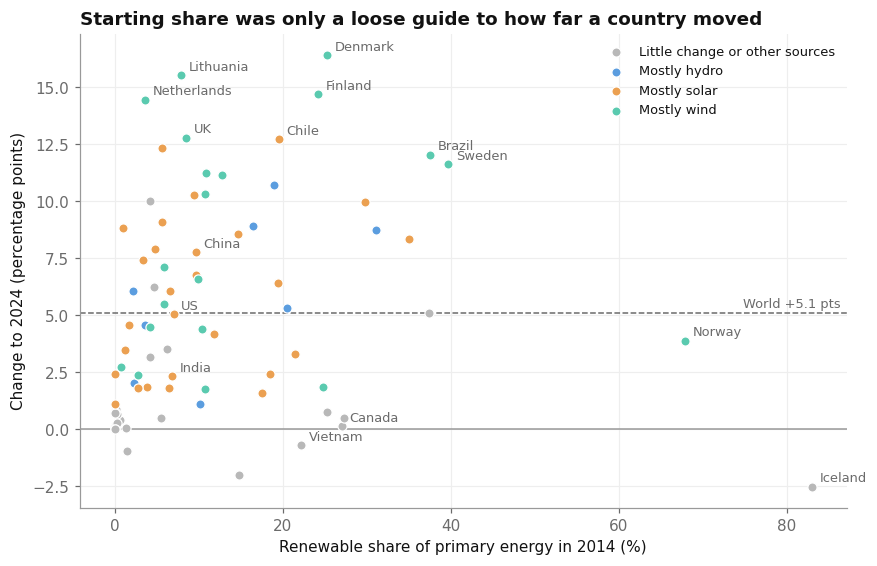

In [10]:
rho = ch[f"total_{BASE}"].corr(ch["d_total"], method="spearman")
print(f"Spearman rank correlation, {BASE} share vs change: {rho:.2f}")

world_change = change.sum()
label = ["Denmark", "Lithuania", "Netherlands", "Finland", "United Kingdom", "Chile", "Sweden", "Brazil",
         "Norway", "Iceland", "Canada", "Vietnam", "China", "United States", "India"]

fig, ax = plt.subplots(figsize=(9, 5.6))
for drv, g in ch.groupby("driver"):
    name = "Little change or other sources" if drv == "flat" else f"Mostly {drv}"
    ax.scatter(g[f"total_{BASE}"], g["d_total"], s=36, color=COLORS[drv], edgecolor="white", linewidth=0.8,
               label=name, zorder=3)
for c in label:
    if c in ch.index:
        ax.annotate(c.replace("United Kingdom", "UK").replace("United States", "US"),
                    (ch.loc[c, f"total_{BASE}"], ch.loc[c, "d_total"]), xytext=(5, 3),
                    textcoords="offset points", fontsize=8.5, color="#6b6b6b")
ax.axhline(0, color="#999999", linewidth=1)
ax.axhline(world_change, color="#6b6b6b", linewidth=1, linestyle="--")
ax.annotate(f"World {world_change:+.1f} pts", (ax.get_xlim()[1], world_change), xytext=(-4, 4),
            textcoords="offset points", ha="right", fontsize=8.5, color="#6b6b6b")
ax.set_xlabel(f"Renewable share of primary energy in {BASE} (%)")
ax.set_ylabel(f"Change to {END} (percentage points)")
ax.set_title("Starting share was only a loose guide to how far a country moved")
ax.legend(frameon=False, fontsize=8.5, loc="upper right")
plt.show()

The correlation is positive but modest. Part of it comes from countries near zero, such as Gulf oil producers, which barely moved at all. Above that, the starting share was a loose guide. The hydro-rich leaders split into two groups. Iceland, Norway and Canada barely moved, while Sweden and Brazil kept climbing on wind and solar. Several of the largest gains came from countries that started low, such as the Netherlands, Lithuania and the UK.

In [11]:
ch.loc[["Iceland", "Norway", "Canada", "New Zealand", "Austria", "Switzerland", "Sweden", "Brazil"], cols]

,total_2014,total_2024,d_total,d_hydro,d_wind,d_solar,d_other,driver
country,,,,,,,,
Iceland,83.01,80.50,-2.51,-4.01,0.01,0.00,1.49,flat
Norway,67.92,71.81,3.89,-2.45,5.56,0.24,0.54,wind
Canada,27.03,27.16,0.13,-2.82,2.16,0.46,0.33,flat
New Zealand,37.46,42.56,5.10,0.01,1.87,0.61,2.61,flat
Austria,35.02,43.35,8.33,0.18,3.05,5.19,-0.09,solar
Switzerland,31.13,39.88,8.75,4.38,0.05,3.72,0.60,hydro
Sweden,39.70,51.32,11.62,-1.09,11.84,1.69,-0.82,wind
Brazil,37.57,49.62,12.05,-0.75,6.03,4.55,2.22,wind


## 7. What drove the change

In [12]:
ch["driver"].map({"hydro": "Mostly hydro", "wind": "Mostly wind", "solar": "Mostly solar",
                  "flat": "Little change or other"}).value_counts().to_frame("countries")

,countries
driver,
Mostly solar,27
Little change or other,24
Mostly wind,20
Mostly hydro,8


Solar was the most common driver, because it spread widely, often from a low base. Wind drove most of the largest gains.

Wind + solar outweighed hydro + other in 87% of the top 15


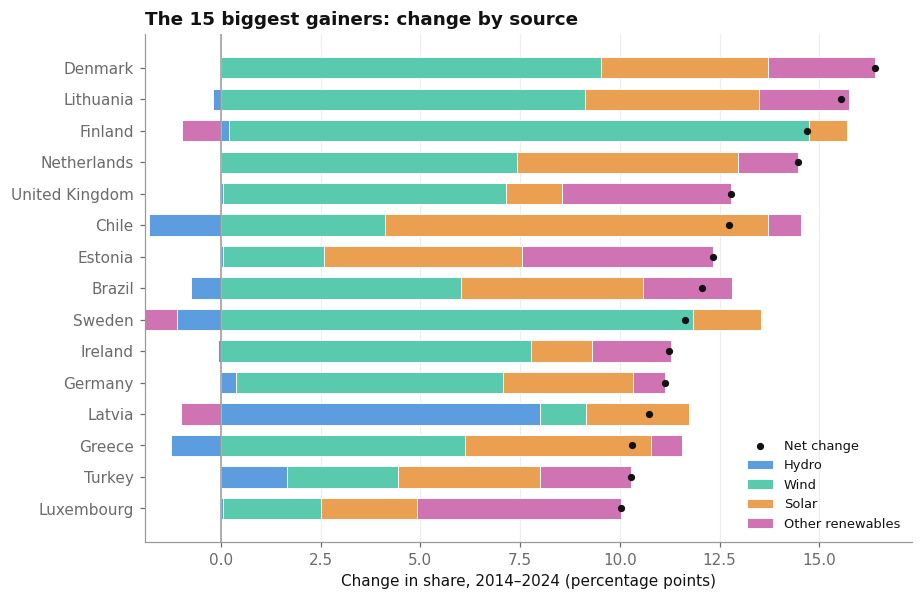

In [13]:
top = ch.sort_values("d_total", ascending=False).head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 6))
pos = pd.Series(0.0, index=top.index)
neg = pd.Series(0.0, index=top.index)
for s in SOURCES:
    v = top[f"d_{s}"]
    left = pos.where(v >= 0, neg + v)
    ax.barh(top.index, v.abs(), left=left, color=COLORS[s], label=LABELS[s], edgecolor="white", linewidth=0.6, height=0.68)
    pos = pos + v.clip(lower=0)
    neg = neg + v.clip(upper=0)
ax.scatter(top["d_total"], top.index, color="#121212", s=14, zorder=4, label="Net change")
ax.axvline(0, color="#999999", linewidth=1)
ax.set_xlabel(f"Change in share, {BASE}–{END} (percentage points)")
ax.set_title("The 15 biggest gainers: change by source")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
ax.grid(axis="y", visible=False)
plt.show()

share_ws = ((top["d_wind"] + top["d_solar"]) > (top["d_hydro"] + top["d_other"])).mean()
print(f"Wind + solar outweighed hydro + other in {share_ws:.0%} of the top 15")

## 8. Where the share fell: Vietnam

Vietnam is the clearest case of an aggregate hiding the story. Its solar build-out after 2019 was one of the fastest anywhere, yet its renewable share ended the decade lower than it started. Hydro's share fell further than wind and solar rose.

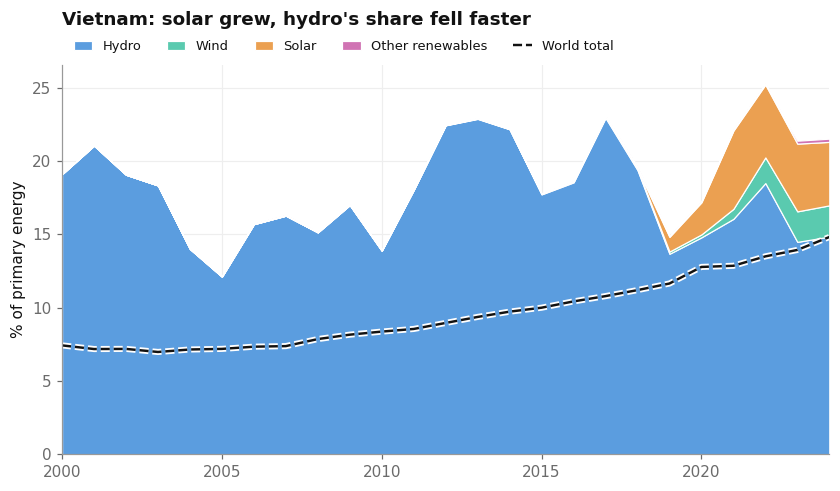

,total_2014,total_2024,d_total,d_hydro,d_wind,d_solar,d_other,driver
country,,,,,,,,
Vietnam,22.22,21.53,-0.69,-7.32,2.11,4.33,0.19,flat
Philippines,14.80,12.82,-1.98,-1.55,0.39,1.40,-2.22,flat
Iceland,83.01,80.50,-2.51,-4.01,0.01,0.00,1.49,flat
Iraq,1.54,0.58,-0.96,-1.05,0.00,0.09,0.00,flat


In [14]:
vn = energy[energy.country == "Vietnam"].set_index("year")
fig, ax = plt.subplots()
ax.stackplot(vn.index, [vn[f"{s}_pct"] for s in SOURCES], colors=[COLORS[s] for s in SOURCES],
             labels=[LABELS[s] for s in SOURCES], edgecolor="white", linewidth=0.8)
import matplotlib.patheffects as pe
ax.plot(world.index, world["renewables_pct"], color="#121212", linestyle="--", linewidth=1.6, label="World total",
        path_effects=[pe.Stroke(linewidth=4, foreground="white"), pe.Normal()])
ax.set_xlim(vn.index.min(), END)
ax.set_ylabel("% of primary energy")
ax.set_title("Vietnam: solar grew, hydro's share fell faster", pad=26)
ax.legend(frameon=False, fontsize=8.5, loc="lower left", bbox_to_anchor=(0, 1.0), ncols=5, handlelength=1.4)
plt.show()

ch.loc[["Vietnam", "Philippines", "Iceland", "Iraq"], cols]

## 9. Robustness: does electricity tell the same story?

Electricity shares run higher than primary-energy shares, because heating and transport still mostly burn fuel directly. If the main findings hold in both measures, they don't depend on the measurement choice. To avoid noise from very small power systems, I keep countries that generated at least 5 TWh in 2024.

In [15]:
big = elec.loc[(elec.year == END) & (elec.generation_twh >= 5), "country"]
ch_e = decade_change(elec[elec.country.isin(set(big) | {"World"})])

w_e = elec[elec.iso_code == "WLD"].set_index("year")
print(f"Electricity, world: wind + solar {w_e.loc[END, 'wind_pct'] + w_e.loc[END, 'solar_pct']:.1f}% "
      f"vs hydro {w_e.loc[END, 'hydro_pct']:.1f}% in {END}")
print(f"Countries in the electricity view: {len(ch_e)}")

both = ch[["d_total"]].join(ch_e[["d_total"]], lsuffix="_energy", rsuffix="_elec", how="inner")
print(f"Rank correlation of decade change across the two measures ({len(both)} countries): "
      f"{both.corr(method='spearman').iloc[0, 1]:.2f}")

Electricity, world: wind + solar 15.0% vs hydro 14.3% in 2024
Countries in the electricity view: 128
Rank correlation of decade change across the two measures (77 countries): 0.91


In [16]:
ch_e.sort_values("d_total", ascending=False)[cols].head(10)

,total_2014,total_2024,d_total,d_hydro,d_wind,d_solar,d_other,driver
country,,,,,,,,
Estonia,11.16,55.75,44.59,0.24,11.95,17.09,15.31,solar
Lithuania,40.92,84.29,43.37,-4.89,28.80,17.04,2.42,wind
Lebanon,1.18,43.82,42.64,12.05,0.13,29.90,0.56,solar
Netherlands,11.42,50.74,39.32,-0.04,21.69,17.12,0.55,wind
Venezuela,55.87,91.13,35.26,35.31,-0.06,0.01,0.00,hydro
Denmark,56.14,89.19,33.05,0.00,17.39,8.91,6.75,wind
Germany,26.18,58.64,32.46,1.63,19.09,9.22,2.52,wind
United Kingdom,19.08,50.65,31.57,0.29,19.86,4.00,7.42,wind
El Salvador,60.16,90.81,30.65,4.21,2.14,19.14,5.16,solar


The crossover holds in electricity too, and the countries that moved are broadly the same in both measures. The electricity view adds some extreme cases from small or stressed power systems. Lebanon's rooftop-solar boom during its fuel crisis is one, and Venezuela's swing towards hydro as its thermal plants fell out of use is another. They are real, but they are about crisis rather than a planned transition. Keep that in mind when reading the electricity rankings.

## 10. Conclusions and limitations

**Conclusions**
- 2024 was the first year wind and solar supplied more of the world's energy than hydropower, in primary energy and in electricity.
- Nearly all of the decade's rise in the global renewable share came from wind and solar.
- The 2014 starting share was only loosely related to the gain (rank correlation 0.36). Iceland, Norway and Canada barely moved, while Sweden and Brazil kept climbing.
- The biggest movers were mostly in Northern Europe, plus Chile and Brazil. Wind drove most of the largest gains, while solar was the most common driver across all countries.
- The ranking of movers holds in electricity as well as primary energy (rank correlation 0.91).

**Limitations**
- Africa is barely covered in the primary-energy series, so "global" means the countries covered.
- Traditional biomass, such as wood and charcoal for cooking, is excluded, which understates renewables in many low-income countries.
- Nuclear is low-carbon but not renewable, so it is excluded. France and Sweden would rank differently on a low-carbon measure.
- The analysis is descriptive. It shows who moved and through which source, not why.

**Next steps**
- Explain the change: test policy, electricity prices and income against each country's change in share.
- Add a low-carbon version (renewables plus nuclear).
- Repeat the analysis on absolute generation in TWh, not only shares, so fast demand growth doesn't hide new capacity.